In [1]:
%run ../setup_env.py

Checking environment...
  ✓ faiss
  ✓ datasets


2026-05-22 17:36:34.849057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/micromamba/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/micromamba/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

  ✓ evaluate
  ✓ accelerate
  ✓ sentencepiece

All packages present — ready to go
FAISS patch applied — version 1.14.1


In [2]:
import os
import sys
import json
import faiss
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import transformers.utils.import_utils as import_utils
import transformers.utils as tu

# faiss patch
if hasattr(import_utils.is_faiss_available, "cache_clear"):
    import_utils.is_faiss_available.cache_clear()
import_utils._faiss_available = True
import_utils.is_faiss_available = lambda: True
tu.is_faiss_available = lambda: True

# paths
REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), "../.."))
FEVER_DIR    = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR     = os.path.join(FEVER_DIR, "data")
RESULTS_DIR  = os.path.join(FEVER_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print(f"Fever dir:   {FEVER_DIR}")
print(f"Data dir:    {DATA_DIR}")
print(f"Results dir: {RESULTS_DIR}")
print(f"FAISS patch: {import_utils.is_faiss_available()}")

Fever dir:   /home/jovyan/lectures/raq-reproducibility-challenge/fever
Data dir:    /home/jovyan/lectures/raq-reproducibility-challenge/fever/data
Results dir: /home/jovyan/lectures/raq-reproducibility-challenge/fever/results
FAISS patch: True


In [3]:
from datasets import load_dataset

# load passages
print("Loading passages...")
passages = []
with open(os.path.join(DATA_DIR, "fever_passages.jsonl")) as f:
    for line in f:
        passages.append(json.loads(line))
print(f"Passages loaded: {len(passages):,}")

# load faiss index
print("Loading FAISS index...")
index = faiss.read_index(
    os.path.join(DATA_DIR, "fever_faiss.index")
)
print(f"Index loaded:    {index.ntotal:,} vectors")

# load fever dataset
print("Loading FEVER dataset...")
dataset = load_dataset("copenlu/fever_gold_evidence")
print(f"Dataset loaded:  {dataset}")

# label mapping
LABEL2ID = {
    "SUPPORTS":        "0",
    "REFUTES":         "1",
    "NOT ENOUGH INFO": "2"
}

def clean_fever_title(title):
    title = title.replace("-LRB-", "(")
    title = title.replace("-RRB-", ")")
    title = title.replace("-LSB-", "[")
    title = title.replace("-RSB-", "]")
    title = title.replace("-LCB-", "{")
    title = title.replace("-RCB-", "}")
    title = title.replace("_", " ")
    return title.strip()

Loading passages...
Passages loaded: 574,197
Loading FAISS index...
Index loaded:    574,197 vectors
Loading FEVER dataset...
Dataset loaded:  DatasetDict({
    train: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 228277
    })
    validation: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 15935
    })
    test: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 16039
    })
})


In [4]:
from transformers import (
    DPRQuestionEncoder,
    DPRQuestionEncoderTokenizerFast
)

print("Loading DPR question encoder...")
q_tokenizer = DPRQuestionEncoderTokenizerFast.from_pretrained(
    "facebook/dpr-question_encoder-single-nq-base"
)
q_encoder = DPRQuestionEncoder.from_pretrained(
    "facebook/dpr-question_encoder-single-nq-base"
).to("cuda")
q_encoder.eval()
print(f"Question encoder loaded on: "
      f"{next(q_encoder.parameters()).device}")

Loading DPR question encoder...


Some weights of the model checkpoint at facebook/dpr-question_encoder-single-nq-base were not used when initializing DPRQuestionEncoder: ['question_encoder.bert_model.pooler.dense.bias', 'question_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRQuestionEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRQuestionEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Question encoder loaded on: cuda:0


In [5]:
def search_index(claim, index, passages, q_encoder,
                 q_tokenizer, n_docs=10):
    """
    Encode a claim with DPR and retrieve top-n passages
    from the FAISS index.
    """
    encoded = q_tokenizer(
        claim,
        return_tensors="pt",
        truncation=True,
        max_length=300
    )
    with torch.no_grad():
        query_vec = q_encoder(
            input_ids=encoded["input_ids"].to("cuda"),
            attention_mask=encoded["attention_mask"].to("cuda")
        ).pooler_output.cpu().numpy()

    faiss.normalize_L2(query_vec)
    scores, indices = index.search(
        query_vec.astype("float32"), n_docs
    )

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "rank":  len(results) + 1,
            "score": float(score),
            "title": passages[idx]["title"],
            "text":  passages[idx]["text"],
            "idx":   int(idx)
        })
    return results

print("Search function defined")

Search function defined


In [6]:
import random
random.seed(42)

# pick 2 examples per label from validation set
examples = []
for label in ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]:
    candidates = [
        ex for ex in dataset["validation"]
        if ex["label"] == label
        and ex["evidence"]
        and ex["evidence"][0][0]   # has a gold article
    ]
    examples.extend(random.sample(candidates, 2))

print(f"Selected {len(examples)} examples\n")

for ex in examples:
    gold_articles = {
        clean_fever_title(ev[0]).lower()
        for ev in ex["evidence"] if ev[0]
    }

    results = search_index(
        ex["claim"], index, passages,
        q_encoder, q_tokenizer, n_docs=5
    )

    print("=" * 65)
    print(f"Label:        {ex['label']}")
    print(f"Claim:        {ex['claim']}")
    print(f"Gold article: {list(gold_articles)}")
    print(f"\nTop 5 retrieved passages:")

    for r in results:
        match = "✓" if any(
            g in r["title"].lower() for g in gold_articles
        ) else " "
        print(f"\n  [{match}] Rank {r['rank']} | "
              f"Score: {r['score']:.3f}")
        print(f"      Title: {r['title']}")
        print(f"      Text:  {r['text'][:120]}...")
    print()

Selected 6 examples

Label:        SUPPORTS
Claim:        Keith Urban was released by a record label.
Gold article: ['keith urban (1999 album)']

Top 5 retrieved passages:

  [ ] Rank 1 | Score: 0.698
      Title: Sony Music
      Text:  per album. George Michael British artist George Michael, signed to Columbia in the U.S. and Epic worldwide, advised Sony...

  [ ] Rank 2 | Score: 0.690
      Title: Motown
      Text:  Supremes and the Temptations, Diana! with Diana Ross, and Goin' Back to Indiana with the Jackson 5. The company loosened...

  [ ] Rank 3 | Score: 0.688
      Title: Keith Urban
      Text:  before moving to the United States the following year. He started a band known as The Ranch, which recorded one studio a...

  [ ] Rank 4 | Score: 0.687
      Title: Bad (album)
      Text:  anniversary, the documentary film, Bad 25, and album, Bad 25, were released in 2012. Background Jackson's sixth solo alb...

  [ ] Rank 5 | Score: 0.687
      Title: The Beach Boys
      Text:  

In [12]:
# sample 200 verifiable examples per label for robust estimates
random.seed(42)

supports_sample = random.sample([
    ex for ex in dataset["validation"]
    if ex["label"] == "SUPPORTS" and ex["evidence"]
    and ex["evidence"][0][0]
], 400)

refutes_sample = random.sample([
    ex for ex in dataset["validation"]
    if ex["label"] == "REFUTES" and ex["evidence"]
    and ex["evidence"][0][0]
], 400)

all_samples = supports_sample + refutes_sample
print(f"Evaluating recall on {len(all_samples)} examples")
print(f"  SUPPORTS: {len(supports_sample)}")
print(f"  REFUTES:  {len(refutes_sample)}")
print(f"\nRunning retrieval — this takes a few minutes...\n")

recalls = {
    "SUPPORTS": {"top1": [], "top5": [], "top10": []},
    "REFUTES":  {"top1": [], "top5": [], "top10": []}
}

for i, ex in enumerate(all_samples):
    if i % 50 == 0:
        print(f"  Progress: {i}/{len(all_samples)}")

    gold_articles = {
        clean_fever_title(ev[0]).lower()
        for ev in ex["evidence"] if ev[0]
    }

    results = search_index(
        ex["claim"], index, passages,
        q_encoder, q_tokenizer, n_docs=10
    )

    retrieved_titles = [r["title"].lower() for r in results]

    top1  = any(g in retrieved_titles[0]  for g in gold_articles)
    top5  = any(g in t for g in gold_articles
                for t in retrieved_titles[:5])
    top10 = any(g in t for g in gold_articles
                for t in retrieved_titles[:10])

    label = ex["label"]
    recalls[label]["top1"].append(top1)
    recalls[label]["top5"].append(top5)
    recalls[label]["top10"].append(top10)

print("\nDone!")

# overall recall
all_top1  = recalls["SUPPORTS"]["top1"]  + recalls["REFUTES"]["top1"]
all_top5  = recalls["SUPPORTS"]["top5"]  + recalls["REFUTES"]["top5"]
all_top10 = recalls["SUPPORTS"]["top10"] + recalls["REFUTES"]["top10"]

print("\n" + "=" * 55)
print("RETRIEVAL RECALL — OVERALL (n=400)")
print("=" * 55)
print(f"Top-1  recall: {np.mean(all_top1):.1%}  "
      f"(paper reports ~71%)")
print(f"Top-5  recall: {np.mean(all_top5):.1%}")
print(f"Top-10 recall: {np.mean(all_top10):.1%}  "
      f"(paper reports ~90%)")

print("\n" + "=" * 55)
print("RECALL BY LABEL")
print("=" * 55)
for label in ["SUPPORTS", "REFUTES"]:
    r = recalls[label]
    print(f"\n  {label} (n={len(r['top1'])}):")
    print(f"    Top-1:  {np.mean(r['top1']):.1%}")
    print(f"    Top-5:  {np.mean(r['top5']):.1%}")
    print(f"    Top-10: {np.mean(r['top10']):.1%}")

Evaluating recall on 800 examples
  SUPPORTS: 400
  REFUTES:  400

Running retrieval — this takes a few minutes...

  Progress: 0/800
  Progress: 50/800
  Progress: 100/800
  Progress: 150/800
  Progress: 200/800
  Progress: 250/800
  Progress: 300/800
  Progress: 350/800
  Progress: 400/800
  Progress: 450/800
  Progress: 500/800
  Progress: 550/800
  Progress: 600/800
  Progress: 650/800
  Progress: 700/800
  Progress: 750/800

Done!

RETRIEVAL RECALL — OVERALL (n=400)
Top-1  recall: 65.4%  (paper reports ~71%)
Top-5  recall: 75.9%
Top-10 recall: 80.0%  (paper reports ~90%)

RECALL BY LABEL

  SUPPORTS (n=400):
    Top-1:  69.2%
    Top-5:  79.8%
    Top-10: 81.8%

  REFUTES (n=400):
    Top-1:  61.5%
    Top-5:  72.0%
    Top-10: 78.2%


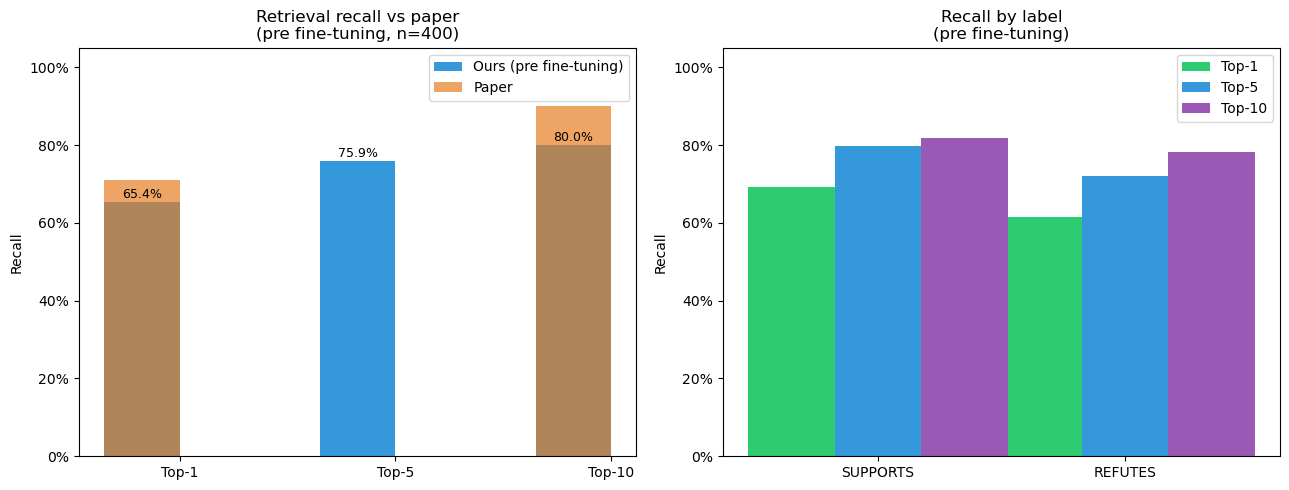

Plot saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: overall recall vs paper
ks      = ["Top-1", "Top-5", "Top-10"]
ours    = [
    np.mean(all_top1),
    np.mean(all_top5),
    np.mean(all_top10)
]
x = np.arange(len(ks))
w = 0.35

bars_ours = axes[0].bar(
    x - w/2, ours, w,
    label="Ours (pre fine-tuning)",
    color="#3498db"
)
# paper only reports top-1 and top-10
axes[0].bar(
    [x[0] - w/2, x[2] - w/2],
    [0.71, 0.90],
    w,
    label="Paper",
    color="#e67e22",
    alpha=0.7
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ks)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Recall")
axes[0].set_title("Retrieval recall vs paper\n(pre fine-tuning, n=400)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)
for bar, val in zip(bars_ours, ours):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.1%}", ha="center", fontsize=9
    )

# right: recall by label
label_names = ["SUPPORTS", "REFUTES"]
top1_by_label  = [np.mean(recalls[l]["top1"])  for l in label_names]
top5_by_label  = [np.mean(recalls[l]["top5"])  for l in label_names]
top10_by_label = [np.mean(recalls[l]["top10"]) for l in label_names]

x2 = np.arange(len(label_names))
axes[1].bar(x2 - w,   top1_by_label,  w, label="Top-1",  color="#2ecc71")
axes[1].bar(x2,       top5_by_label,  w, label="Top-5",  color="#3498db")
axes[1].bar(x2 + w,   top10_by_label, w, label="Top-10", color="#9b59b6")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(label_names)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Recall")
axes[1].set_title("Recall by label\n(pre fine-tuning)")
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "retrieval_verification.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved")

In [14]:
recall_summary = {
    "n_examples":      len(all_samples),
    "n_supports":      len(supports_sample),
    "n_refutes":       len(refutes_sample),
    "overall": {
        "top1_recall":  round(float(np.mean(all_top1)),  3),
        "top5_recall":  round(float(np.mean(all_top5)),  3),
        "top10_recall": round(float(np.mean(all_top10)), 3),
    },
    "by_label": {
        label: {
            "top1":  round(float(np.mean(recalls[label]["top1"])),  3),
            "top5":  round(float(np.mean(recalls[label]["top5"])),  3),
            "top10": round(float(np.mean(recalls[label]["top10"])), 3),
        }
        for label in ["SUPPORTS", "REFUTES"]
    },
    "paper": {
        "top1_recall":  0.71,
        "top10_recall": 0.90,
        "note": "Paper reports on full Wikipedia index, 21M passages"
    },
    "our_index": {
        "n_passages": 574197,
        "n_articles": 23733,
        "coverage":   0.798,
        "dump":       "wikimedia/wikipedia 20231101.en"
    },
    "note": (
        "Pre fine-tuning recall on FEVER validation set. "
        "REFUTES recall expected to be lower — retriever fetches "
        "passages about entities mentioned in the false claim "
        "rather than the gold evidence article."
    )
}

save_path = os.path.join(RESULTS_DIR, "retrieval_recall.json")
with open(save_path, "w") as f:
    json.dump(recall_summary, f, indent=2)

print("Recall summary saved")
print(json.dumps(recall_summary, indent=2))

Recall summary saved
{
  "n_examples": 800,
  "n_supports": 400,
  "n_refutes": 400,
  "overall": {
    "top1_recall": 0.654,
    "top5_recall": 0.759,
    "top10_recall": 0.8
  },
  "by_label": {
    "SUPPORTS": {
      "top1": 0.693,
      "top5": 0.797,
      "top10": 0.818
    },
    "REFUTES": {
      "top1": 0.615,
      "top5": 0.72,
      "top10": 0.782
    }
  },
  "paper": {
    "top1_recall": 0.71,
    "top10_recall": 0.9,
    "note": "Paper reports on full Wikipedia index, 21M passages"
  },
  "our_index": {
    "n_passages": 574197,
    "n_articles": 23733,
    "coverage": 0.798,
    "dump": "wikimedia/wikipedia 20231101.en"
  },
  "note": "Pre fine-tuning recall on FEVER validation set. REFUTES recall expected to be lower \u2014 retriever fetches passages about entities mentioned in the false claim rather than the gold evidence article."
}
